# Análise Exploratória dos Dados

Este notebook apresenta a análise exploratória da base de clientes utilizada no projeto.

O objetivo é compreender o comportamento das variáveis e investigar quais fatores relacionados ao perfil do cliente, ao pedido, à entrega e ao atendimento podem estar associados ao nível de satisfação representado pelo NPS.

A análise será conduzida de forma descritiva e visual, com foco na identificação de padrões, diferenças entre grupos e possíveis relações entre as variáveis.

> Importante: os resultados desta etapa indicam associações presentes nos dados, mas não permitem estabelecer relações de causa e efeito.

## 1. Preparação do ambiente

Nesta etapa serão importadas as bibliotecas utilizadas para manipulação dos dados, análise estatística e criação das visualizações.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

sns.set_theme(
    style="whitegrid",
    palette="deep"
)

## 2. Leitura e visão geral da base

A análise exploratória será realizada a partir da base tratada no notebook anterior.

Nesta etapa inicial, serão verificadas as dimensões do conjunto de dados, os tipos das variáveis, as estatísticas descritivas e a presença de valores ausentes ou registros duplicados.

Essa verificação permite confirmar que a base está consistente e pronta para as análises visuais e comparativas das próximas etapas.

In [ ]:
# Fazendo a Leitura da Base de Dados
dados = pd.read_csv("../data/processed/clientes_tratados.csv")

dados.head()

,idade_cliente,regiao_cliente,tempo_cliente_meses,valor_pedido,quantidade_itens,valor_desconto,parcelas_pagamento,tempo_entrega_dias,atraso_entrega_dias,valor_frete,tentativas_entrega,contatos_atendimento,tempo_resolucao_dias,nps,numero_reclamacoes
0,63,Nordeste,14,139.73,4,39.35,4,2,2,55.53,3,0,4,6.9,3
1,20,Sul,1,458.95,2,9.51,10,6,4,28.23,3,0,10,2.4,3
2,46,Nordeste,111,507.06,5,42.82,6,6,1,40.99,1,4,5,4.8,7
3,52,Centro-Oeste,117,302.19,2,19.58,9,5,2,35.24,3,1,11,5.9,4
4,56,Norte,50,253.06,1,29.37,11,13,1,39.32,1,1,0,6.1,3


In [ ]:
# Verificando o tamanho do dataset
print(f'Total de linhas {dados.shape[0]}')
print(f'Total de colunas {dados.shape[1]}')

Total de linhas 2500
Total de colunas 15


In [ ]:
# verificando os tipos dos dados
dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   idade_cliente         2500 non-null   int64  
 1   regiao_cliente        2500 non-null   object 
 2   tempo_cliente_meses   2500 non-null   int64  
 3   valor_pedido          2500 non-null   float64
 4   quantidade_itens      2500 non-null   int64  
 5   valor_desconto        2500 non-null   float64
 6   parcelas_pagamento    2500 non-null   int64  
 7   tempo_entrega_dias    2500 non-null   int64  
 8   atraso_entrega_dias   2500 non-null   int64  
 9   valor_frete           2500 non-null   float64
 10  tentativas_entrega    2500 non-null   int64  
 11  contatos_atendimento  2500 non-null   int64  
 12  tempo_resolucao_dias  2500 non-null   int64  
 13  nps                   2500 non-null   float64
 14  numero_reclamacoes    2500 non-null   int64  
dtypes: float64(4), int64(

In [ ]:
# verificando sua estatistica descritiva
dados.describe().round(2)

,idade_cliente,tempo_cliente_meses,valor_pedido,quantidade_itens,valor_desconto,parcelas_pagamento,tempo_entrega_dias,atraso_entrega_dias,valor_frete,tentativas_entrega,contatos_atendimento,tempo_resolucao_dias,nps,numero_reclamacoes
count,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00
mean,43.40,61.32,434.26,3.47,29.75,6.00,8.02,2.19,38.22,2.01,1.52,5.49,4.38,4.15
std,14.89,34.48,289.77,1.69,29.23,3.16,3.77,1.45,12.08,0.82,1.23,3.46,2.51,1.78
min,18.00,1.00,7.76,1.00,0.02,1.00,2.00,0.00,2.62,1.00,0.00,0.00,0.00,0.00
25%,31.00,31.00,220.24,2.00,8.88,3.00,5.00,1.00,29.93,1.00,1.00,2.00,2.60,3.00
50%,43.00,62.00,375.52,3.00,20.94,6.00,8.00,2.00,38.50,2.00,1.00,6.00,4.40,4.00
75%,56.00,91.00,577.29,5.00,40.83,9.00,11.00,3.00,46.27,3.00,2.00,8.00,6.10,5.00
max,69.00,119.00,1983.81,6.00,230.33,11.00,14.00,8.00,76.13,3.00,7.00,11.00,10.00,11.00


In [ ]:
# total de valores ausentes e duplicados
print(f"Valores ausentes: {dados.isna().sum().sum()}")
print(f"Linhas duplicadas: {dados.duplicated().sum()}")

Valores ausentes: 0
Linhas duplicadas: 0


### Observações iniciais

A base possui 2.500 registros e 15 variáveis, sem presença de valores ausentes ou linhas duplicadas.

As variáveis representam características do cliente, informações do pedido, indicadores de entrega, atendimento e satisfação.

A maior parte das variáveis é numérica, enquanto `regiao_cliente` é a única variável categórica da base.

Com essa estrutura validada, a análise seguirá para a investigação da variável NPS e das demais características presentes no conjunto de dados.

## 3. Análise da variável NPS

A variável `nps` representa a nota atribuída pelo cliente à sua experiência com a empresa.

Nesta etapa, será analisada a distribuição das notas, considerando medidas de tendência central, dispersão e concentração dos valores.

Também será verificado se as observações estão dentro da escala esperada, de 0 a 10, antes da criação das categorias de detratores, neutros e promotores.

In [ ]:
dados['nps'].describe().round(2)

,nps
count,2500.00
mean,4.38
std,2.51
min,0.00
25%,2.60
50%,4.40
75%,6.10
max,10.00


### Observações iniciais

A variável `nps` possui 2.500 observações, com notas variando entre 0 e 10.

A média das avaliações é de 4,38, enquanto a mediana é de 4,40, indicando concentração das respostas em níveis relativamente baixos de satisfação.

O primeiro quartil está em 2,60 e o terceiro quartil em 6,10, mostrando que 50% das avaliações estão distribuídas entre esses dois valores.

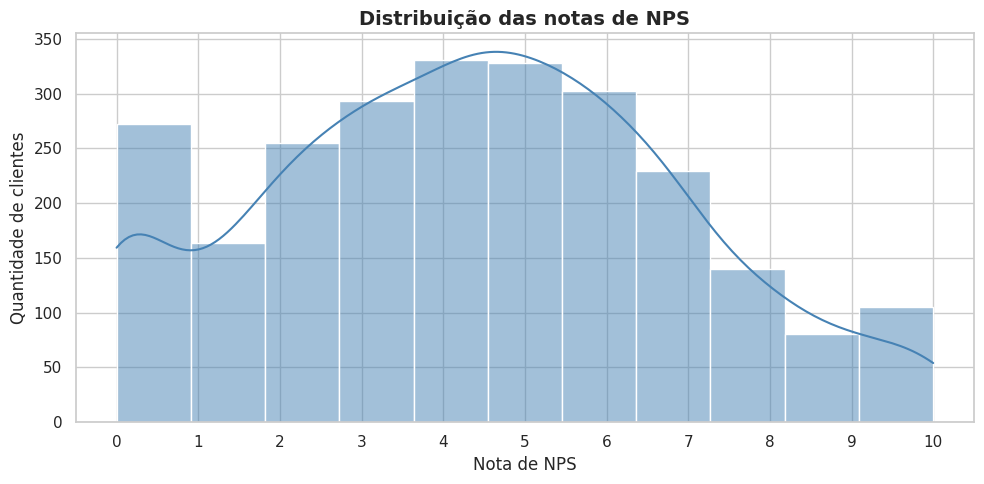

In [ ]:
# Plotando o Histograma do NPS
plt.figure(figsize=(10, 5))

sns.histplot(
    data=dados,
    x="nps",
    bins=11,
    kde=True,
    color="steelblue"
)

plt.title(
    "Distribuição das notas de NPS",
    fontsize=14,
    fontweight="bold"
)
plt.xlabel("Nota de NPS")
plt.ylabel("Quantidade de clientes")

plt.xticks(range(0, 11))
plt.tight_layout()
plt.show()

### Distribuição das notas

A distribuição mostra maior concentração de avaliações em faixas intermediárias e baixas, com destaque para notas próximas de 4 e 5.

Também é possível observar uma quantidade relevante de clientes com nota igual a zero, o que pode representar experiências fortemente negativas.

As notas mais altas, especialmente 9 e 10, aparecem com menor frequência, sugerindo uma participação mais reduzida de clientes altamente satisfeitos.

## 4. Classificação dos clientes pelo NPS

Para facilitar a interpretação dos resultados, as notas de NPS serão agrupadas nas três categorias tradicionais do indicador:

- **Detratores:** notas entre 0 e 6;
- **Neutros:** notas 7 e 8;
- **Promotores:** notas 9 e 10.

Essa classificação permite comparar o comportamento dos clientes e investigar quais características estão associadas a níveis mais altos ou mais baixos de satisfação.

In [ ]:
# Criando a classe dos NPS
dados['classe_nps'] = pd.cut(dados['nps'],
                             bins=[-1, 6., 8., np.inf],
                             labels=['Detratores', 'Neutros', 'Promotores'])

In [ ]:
# Verifcando a quantidade de cada classe
ordem_classes = [
    "Detratores",
    "Neutros",
    "Promotores"
]

quantidade_classes = dados["classe_nps"].value_counts().reindex(ordem_classes)
quantidade_classes

,count
classe_nps,
Detratores,1851
Neutros,448
Promotores,201


In [ ]:
# Mostrando em porcentagem a distribuição dos dados
percentual_classes = dados['classe_nps'].value_counts(normalize=True).reindex(ordem_classes).round(2)*100
percentual_classes

,proportion
classe_nps,
Detratores,74.0
Neutros,18.0
Promotores,8.0


In [ ]:
# Trazendo o resumo de cada classe - quantidade e percentual
resumo_classes = pd.DataFrame({
    "quantidade": quantidade_classes,
    "percentual": percentual_classes
})

resumo_classes

,quantidade,percentual
classe_nps,,
Detratores,1851,74.0
Neutros,448,18.0
Promotores,201,8.0


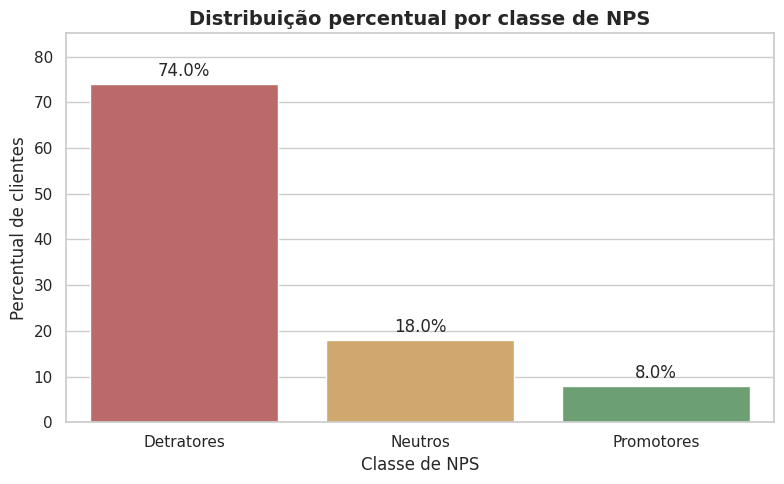

In [ ]:
# Plotando a porcentagem de cada classe
plt.figure(figsize=(8, 5))

cores_nps = {
    "Detratores": "#C85C5C",
    "Neutros": "#E0AA5E",
    "Promotores": "#63A96B"
}

ax = sns.barplot(
    x=percentual_classes.index,
    y=percentual_classes.values,
    hue=percentual_classes.index,
    palette=cores_nps,
    legend=False
)

plt.title(
    "Distribuição percentual por classe de NPS",
    fontsize=14,
    fontweight="bold"
)
plt.xlabel("Classe de NPS")
plt.ylabel("Percentual de clientes")

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        padding=3
    )

plt.ylim(0, percentual_classes.max() * 1.15)
plt.tight_layout()
plt.show()

### Distribuição das classes

A maior parte dos clientes foi classificada como detratora, representando aproximadamente 74% da base.

Os clientes neutros correspondem a cerca de 18%, enquanto os promotores representam apenas 8% das observações.

Esse resultado indica um cenário de baixa satisfação, com forte concentração de avaliações entre 0 e 6. A diferença entre as classes também deverá ser considerada nas próximas análises, pois o número de detratores é significativamente maior do que o de promotores.

## 5. Distribuição das variáveis

Nesta etapa, as variáveis serão analisadas individualmente para compreender seus padrões de distribuição, concentração, dispersão e possíveis valores extremos.

As variáveis numéricas serão avaliadas por meio de histogramas, enquanto a variável categórica `regiao_cliente` será analisada pela frequência de clientes em cada região.

Essa análise permite identificar características importantes da base antes das comparações com as classes de NPS.

In [ ]:
variaveis_numericas = dados.select_dtypes(
    include="number"
).columns.tolist()

variaveis_numericas.remove("nps")

variaveis_numericas

['idade_cliente',
 'tempo_cliente_meses',
 'valor_pedido',
 'quantidade_itens',
 'valor_desconto',
 'parcelas_pagamento',
 'tempo_entrega_dias',
 'atraso_entrega_dias',
 'valor_frete',
 'tentativas_entrega',
 'contatos_atendimento',
 'tempo_resolucao_dias',
 'numero_reclamacoes']

### 5.1 Distribuição das variáveis numéricas

Os histogramas permitem observar o formato das distribuições e identificar variáveis simétricas, assimétricas, discretas ou com possíveis valores extremos.

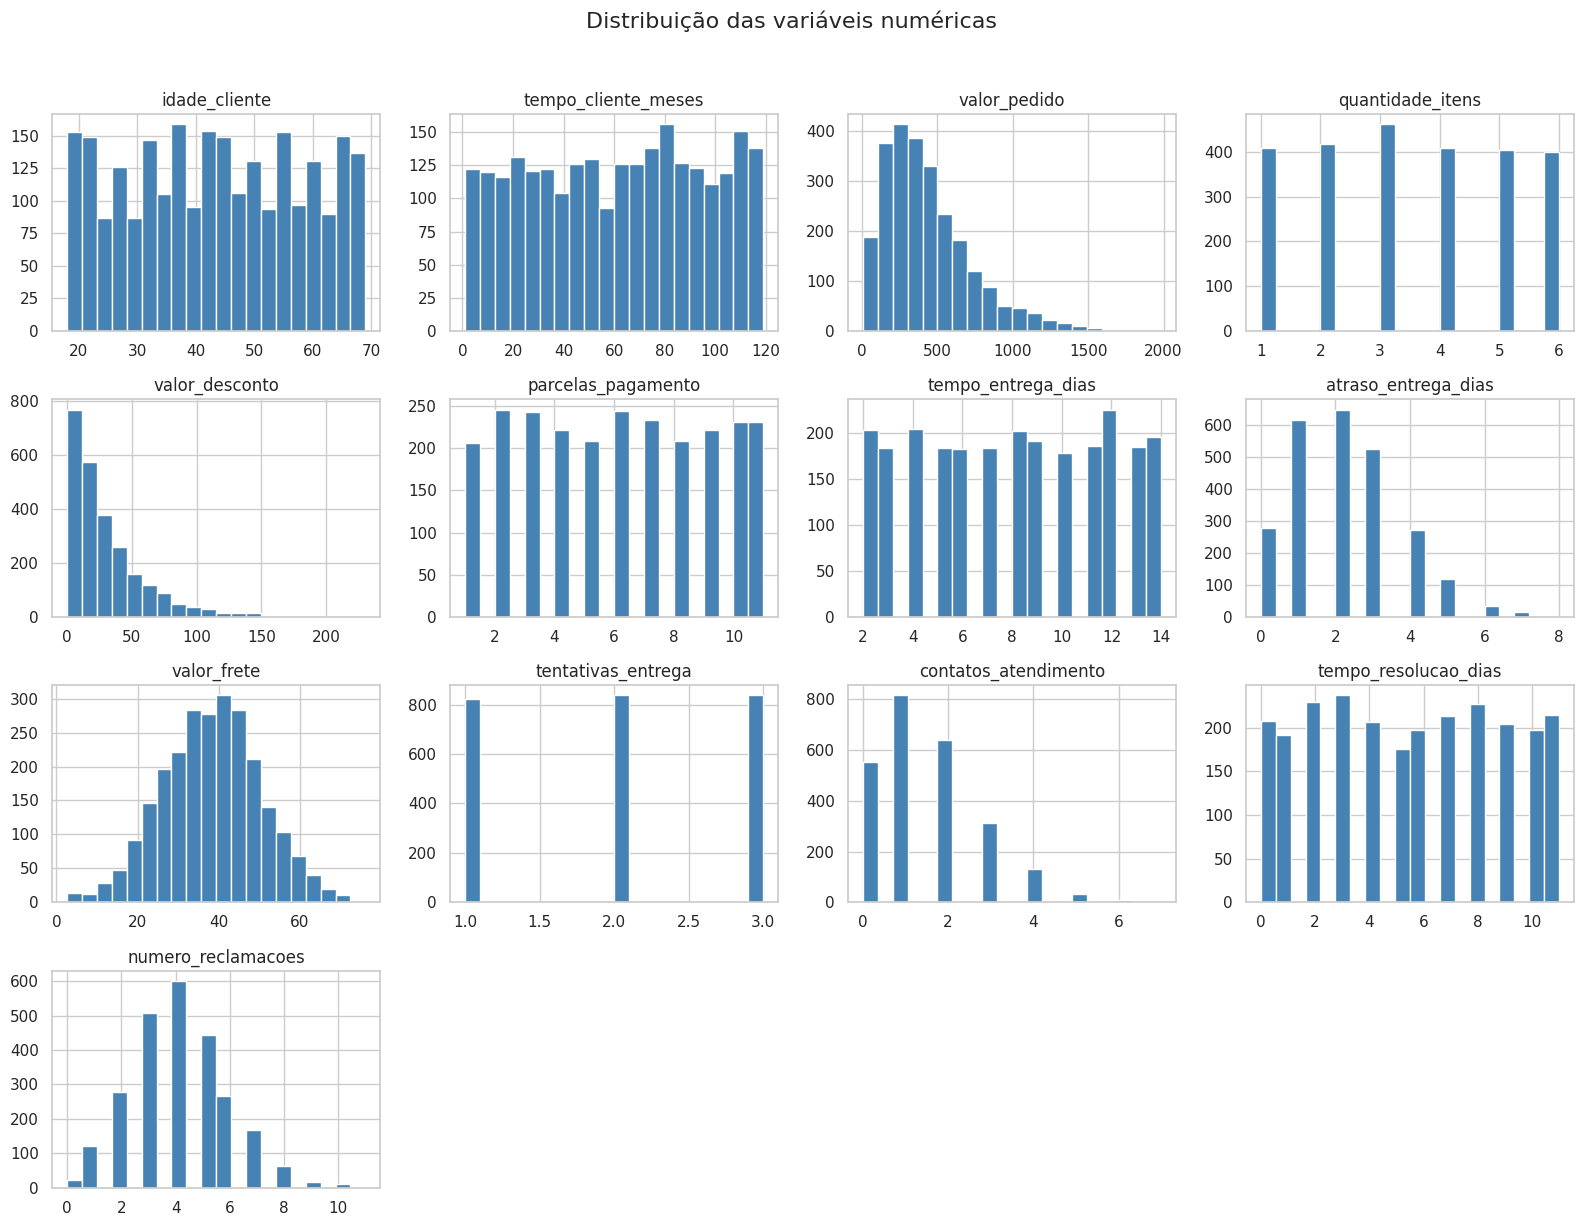

In [ ]:
dados[variaveis_numericas].hist(
    figsize=(16, 12),
    bins=20,
    color="steelblue",
    edgecolor="white"
)

plt.suptitle(
    "Distribuição das variáveis numéricas",
    fontsize=16,
    y=1.02
)

plt.tight_layout()
plt.show()

### Principais observações

As variáveis apresentam comportamentos distintos.

`valor_pedido` e `valor_desconto` possuem distribuição assimétrica à direita, com maior concentração em valores menores e poucos registros de valores elevados.

As variáveis `quantidade_itens`, `parcelas_pagamento`, `tentativas_entrega` e `contatos_atendimento` possuem natureza discreta, apresentando valores inteiros e concentrações específicas.

A variável `valor_frete` apresenta uma distribuição mais próxima da simetria, enquanto `numero_reclamacoes` concentra a maior parte dos clientes em valores intermediários.

Esses padrões serão analisados posteriormente em relação às classes de NPS.

### 5.2 Distribuição dos clientes por região

A variável `regiao_cliente` será analisada para verificar como os clientes estão distribuídos geograficamente.

Essa análise é importante para identificar possíveis desequilíbrios na base e garantir que comparações regionais sejam interpretadas considerando a quantidade de clientes em cada grupo.

In [ ]:
distribuicao_regioes = (
    dados["regiao_cliente"]
    .value_counts()
    .rename_axis("regiao")
    .reset_index(name="quantidade_clientes")
)

distribuicao_regioes

,regiao,quantidade_clientes
0,Sul,521
1,Sudeste,520
2,Norte,506
3,Nordeste,485
4,Centro-Oeste,468


In [ ]:
distribuicao_regioes["percentual"] = (
    distribuicao_regioes["quantidade_clientes"]
    / distribuicao_regioes["quantidade_clientes"].sum()
    * 100
).round(2)

distribuicao_regioes

,regiao,quantidade_clientes,percentual
0,Sul,521,20.84
1,Sudeste,520,20.80
2,Norte,506,20.24
3,Nordeste,485,19.40
4,Centro-Oeste,468,18.72


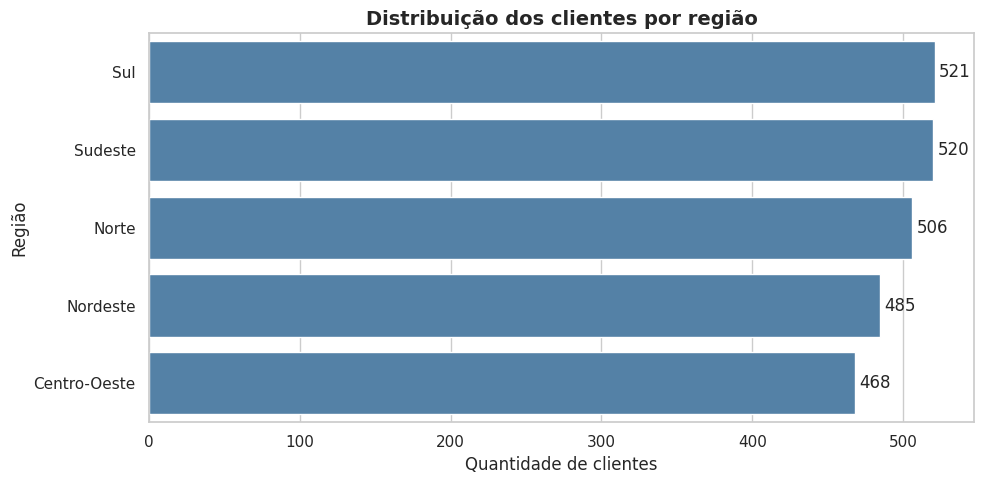

In [ ]:
ordem_regioes = (
    dados["regiao_cliente"]
    .value_counts()
    .index
)

plt.figure(figsize=(10, 5))

ax = sns.countplot(
    data=dados,
    y="regiao_cliente",
    order=ordem_regioes,
    color="steelblue"
)

plt.title(
    "Distribuição dos clientes por região",
    fontsize=14,
    fontweight="bold"
)
plt.xlabel("Quantidade de clientes")
plt.ylabel("Região")

for container in ax.containers:
    ax.bar_label(container, padding=3)

plt.tight_layout()
plt.show()

### Distribuição regional

A distribuição de clientes entre as regiões é relativamente equilibrada.

As regiões Sul e Sudeste apresentam as maiores quantidades de clientes, enquanto o Centro-Oeste possui a menor participação.

Como as diferenças entre as regiões não são muito elevadas, a base apresenta condições adequadas para comparações regionais posteriores.

## 6. Principais fatores associados ao NPS

Após a análise das variáveis de perfil, pedido, entrega e atendimento, dois fatores apresentaram diferenças mais evidentes entre detratores, neutros e promotores:

- `atraso_entrega_dias`;
- `numero_reclamacoes`.

Essas variáveis serão analisadas com maior profundidade por apresentarem maior capacidade de diferenciar os níveis de satisfação dos clientes.

In [ ]:
def plotar_distribuicoes_por_classe(dados, variavel):
    fig, axes = plt.subplots(
        1,
        3,
        figsize=(16, 4.5)
    )

    sns.boxplot(
        data=dados,
        x="classe_nps",
        y=variavel,
        order=ordem_classes,
        hue="classe_nps",
        palette=cores_nps,
        legend=False,
        ax=axes[0]
    )

    axes[0].set_title(f"Boxplot de {variavel}")
    axes[0].set_xlabel("Classe de NPS")
    axes[0].set_ylabel(variavel)

    sns.violinplot(
        data=dados,
        x="classe_nps",
        y=variavel,
        order=ordem_classes,
        hue="classe_nps",
        palette=cores_nps,
        legend=False,
        inner="quartile",
        ax=axes[1]
    )

    axes[1].set_title(f"Distribuição de {variavel}")
    axes[1].set_xlabel("Classe de NPS")
    axes[1].set_ylabel(variavel)

    sns.kdeplot(
        data=dados,
        x=variavel,
        hue="classe_nps",
        hue_order=ordem_classes,
        palette=cores_nps,
        fill=True,
        common_norm=False,
        alpha=0.25,
        ax=axes[2]
    )

    axes[2].set_title(f"Densidade de {variavel}")
    axes[2].set_xlabel(variavel)
    axes[2].set_ylabel("Densidade")

    plt.tight_layout()
    plt.show()

### 6.1 Atraso na entrega

O atraso na entrega apresentou diferenças claras entre as classes de NPS.

Os clientes detratores concentram-se em níveis mais elevados de atraso e apresentam maior dispersão dos valores. Os promotores, por outro lado, estão mais concentrados em entregas sem atraso ou com atrasos reduzidos.

Esse padrão sugere uma associação entre o cumprimento do prazo e a satisfação do cliente.

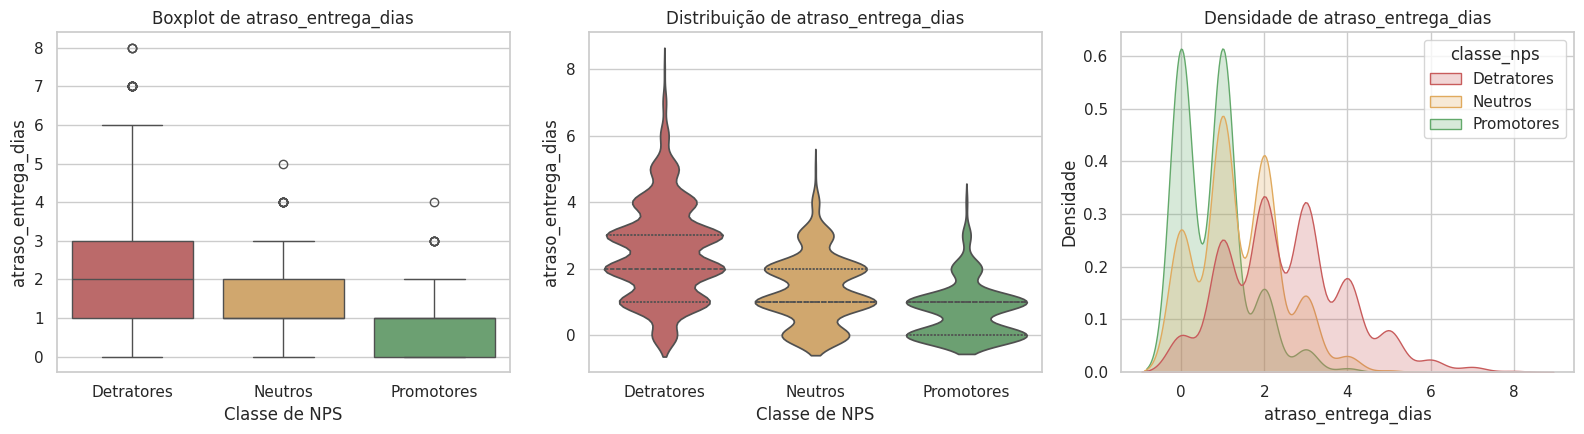

In [ ]:
# Pegando os gráficos de atraso de entrega
plotar_distribuicoes_por_classe(
    dados,
    "atraso_entrega_dias"
)

### 6.2 Número de reclamações

O número de reclamações também apresentou forte diferença entre as classes de NPS.

Os detratores concentram-se em níveis mais altos de reclamações, enquanto os promotores apresentam maior frequência de poucos registros de insatisfação.

Esse comportamento indica uma associação entre a recorrência de problemas ao longo da jornada e avaliações mais baixas.

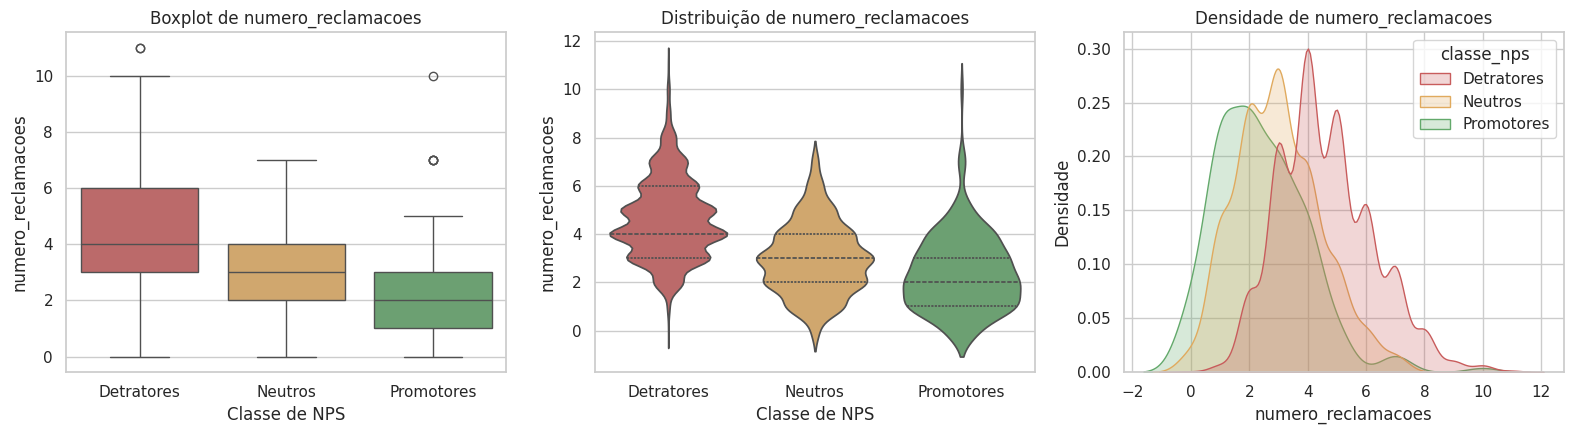

In [ ]:
plotar_distribuicoes_por_classe(
    dados,
    "numero_reclamacoes"
)

### 6.3 Satisfação por faixa de atraso

Após identificar o atraso na entrega como uma das variáveis mais associadas ao
NPS, será analisado como a satisfação dos clientes se comporta em diferentes
faixas de atraso.

O objetivo é verificar se existe uma redução progressiva da nota média à medida
que o atraso aumenta e identificar faixas que possam representar maior risco de
insatisfação.

As faixas foram definidas para facilitar a interpretação do comportamento dos
clientes e apoiar possíveis decisões operacionais.

In [ ]:
# Criando as faixas de atraso
dados["faixa_atraso"] = pd.cut(
    dados["atraso_entrega_dias"],
    bins=[-1, 0, 2, 4, 6, np.inf],
    labels=[
        "Sem atraso",
        "1 a 2 dias",
        "3 a 4 dias",
        "5 a 6 dias",
        "Acima de 6 dias"
    ]
)

In [ ]:
# Criando a tabela resumo da faixa de atraso
analise_atraso = (
    dados.groupby(
        "faixa_atraso",
        observed=False
    )
    .agg(
        quantidade_clientes=("nps", "size"),
        nota_media=("nps", "mean"),
        nota_mediana=("nps", "median"),
        percentual_detratores=(
            "classe_nps",
            lambda coluna: coluna.eq("Detratores").mean() * 100
        )
    )
    .reset_index()
    .round(2)
)

analise_atraso

,faixa_atraso,quantidade_clientes,nota_media,nota_mediana,percentual_detratores
0,Sem atraso,277,6.86,6.8,36.46
1,1 a 2 dias,1261,5.05,5.0,67.72
2,3 a 4 dias,795,3.10,3.0,91.82
3,5 a 6 dias,150,1.39,0.9,99.33
4,Acima de 6 dias,17,0.24,0.0,100.00


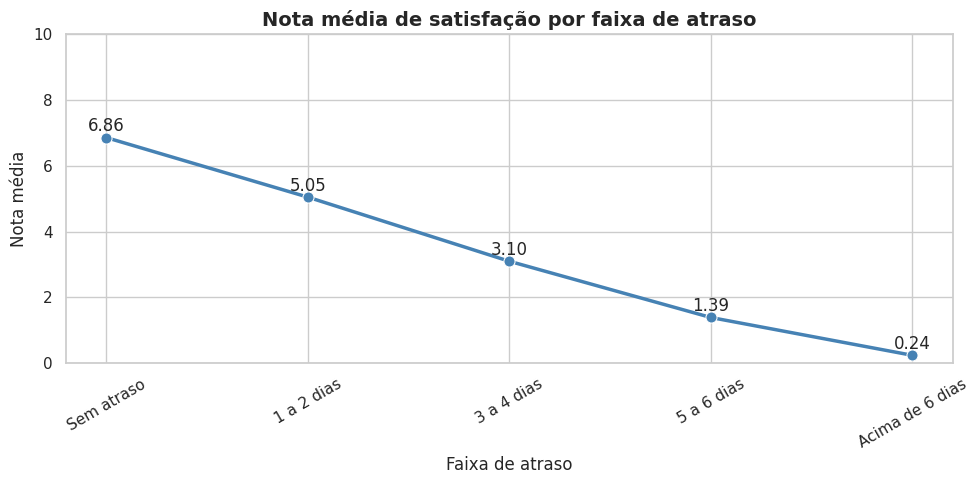

In [ ]:
# Plotando o gráfico da nota média
plt.figure(figsize=(10, 5))

ax = sns.lineplot(
    data=analise_atraso,
    x="faixa_atraso",
    y="nota_media",
    marker="o",
    linewidth=2.5,
    markersize=8,
    color="steelblue"
)

plt.title(
    "Nota média de satisfação por faixa de atraso",
    fontsize=14,
    fontweight="bold"
)
plt.xlabel("Faixa de atraso")
plt.ylabel("Nota média")
plt.ylim(0, 10)

for indice, linha in analise_atraso.iterrows():
    ax.text(
        indice,
        linha["nota_media"] + 0.2,
        f'{linha["nota_media"]:.2f}',
        ha="center"
    )

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

#### Interpretação

Os resultados mostram uma queda consistente da satisfação à medida que o atraso na entrega aumenta.

Clientes que receberam seus pedidos sem atraso apresentaram nota média de 6,86. Quando o atraso foi de 1 a 2 dias, a nota média caiu para 5,05. Entre 3 e 4 dias de atraso, a média reduziu para 3,10, enquanto atrasos de 5 a 6 dias apresentaram nota média de apenas 1,39.

Nos casos com mais de 6 dias de atraso, a nota média foi de 0,24, indicando um nível extremamente baixo de satisfação. Esse grupo, porém, possui apenas 17 clientes, portanto deve ser interpretado com cautela devido ao tamanho reduzido da amostra.

O percentual de detratores também cresce de forma expressiva entre as faixas: 36,46% entre clientes sem atraso, 67,72% para atrasos de 1 a 2 dias, 91,82% entre 3 e 4 dias, 99,33% entre 5 e 6 dias e 100% acima de 6 dias.

Esse padrão indica uma forte associação entre atraso na entrega e redução da satisfação. A faixa entre 1 e 2 dias já apresenta deterioração relevante, enquanto atrasos superiores a 2 dias representam um cenário crítico, com predominância de clientes detratores.

Embora a análise seja descritiva e não comprove causalidade, os resultados sugerem que o controle dos prazos de entrega deve ser tratado como prioridade operacional para preservar a experiência do cliente.

## 7. Criação de variáveis derivadas

Com base nos padrões identificados durante a análise exploratória, serão criadas variáveis binárias para representar situações potencialmente críticas na experiência do cliente.

As novas variáveis sintetizam eventos relacionados a atraso, dificuldade de atendimento e recorrência de reclamações, facilitando a comparação entre clientes expostos e não expostos a esses problemas.

As variáveis criadas serão:

- `atraso_critico`: indica atraso igual ou superior a 2 dias;
- `problema_complexo`: indica clientes com pelo menos 2 contatos com o atendimento e tempo de resolução igual ou superior a 3 dias;
- `reclamacao_recorrente`: indica clientes com 3 ou mais reclamações.

In [ ]:
# Fazendo a criação das variáveis
dados["atraso_critico"] = (
    dados["atraso_entrega_dias"] >= 2
).astype(int)

dados["problema_complexo"] = (
    (dados["contatos_atendimento"] >= 2)
    & (dados["tempo_resolucao_dias"] >= 3)
).astype(int)

dados["reclamacao_recorrente"] = (
    dados["numero_reclamacoes"] >= 3
).astype(int)

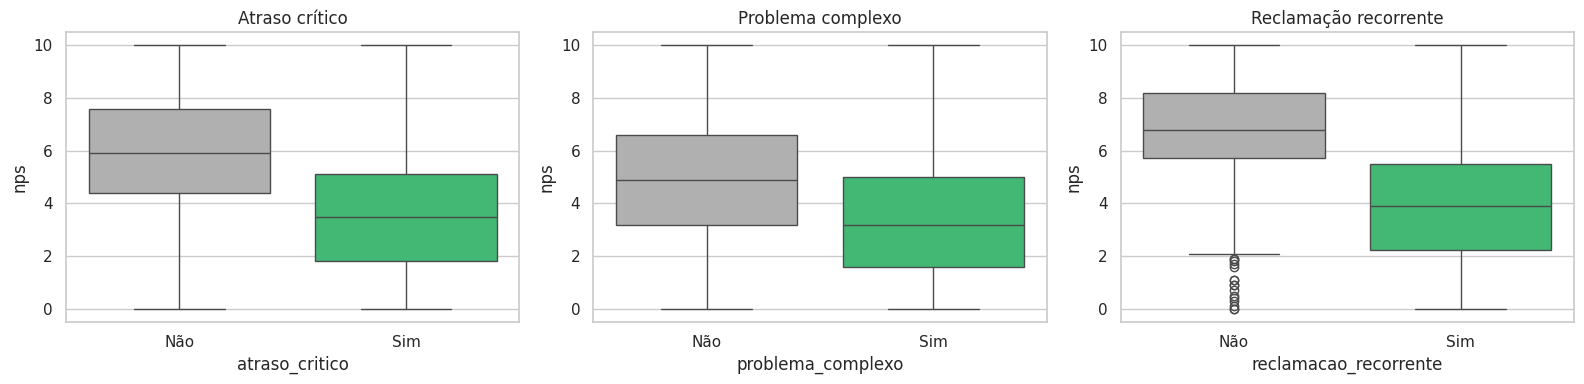

In [ ]:
plt.figure(figsize=(16,4))

palette = {
        1: '#2ecc71',
        0: '#b0b0b0'
    }

plt.subplot(1,3,1)
sns.boxplot(x='atraso_critico', y='nps', hue='atraso_critico',
            data=dados, palette=palette, order=[0,1], legend=False)
plt.title('Atraso crítico')
plt.xticks([0,1], ['Não', 'Sim'])

plt.subplot(1,3,2)
sns.boxplot(x='problema_complexo', y='nps', hue='problema_complexo',
            data=dados, palette=palette, order=[0,1], legend=False)
plt.title('Problema complexo')
plt.xticks([0,1], ['Não', 'Sim'])

plt.subplot(1,3,3)
sns.boxplot(x='reclamacao_recorrente', y='nps', hue='reclamacao_recorrente',
            data=dados, palette=palette, order=[0,1], legend=False)
plt.title('Reclamação recorrente')
plt.xticks([0,1], ['Não', 'Sim'])

plt.tight_layout()
plt.show()

### Interpretação

As variáveis derivadas apresentam diferenças claras nos níveis de satisfação dos clientes.

Clientes classificados com `atraso_critico` apresentam notas de NPS mais baixas do que aqueles que não enfrentaram atrasos relevantes. A mediana do grupo sem atraso crítico está próxima de 6, enquanto o grupo com atraso crítico apresenta mediana em torno de 3,5.

A variável `problema_complexo` também diferencia os grupos. Clientes que precisaram de mais contatos com o atendimento e tiveram maior tempo de resolução apresentam notas inferiores, indicando que a dificuldade para solucionar problemas está associada a uma pior experiência.

O contraste mais forte aparece em `reclamacao_recorrente`. Clientes com três ou mais reclamações apresentam uma queda acentuada no NPS, com mediana próxima de 4, enquanto os demais clientes apresentam mediana próxima de 7.

De forma geral, os resultados sugerem que atrasos relevantes, dificuldades no atendimento e recorrência de reclamações estão associados a níveis mais baixos de satisfação. Entre os fatores analisados, a recorrência de reclamações apresenta a separação mais evidente entre os grupos.

# 8. Correlação das Variáveis

A análise de correlação foi utilizada para identificar quais variáveis numéricas apresentam maior relação linear com o NPS.

Foram consideradas as correlações das variáveis numéricas com a variável `nps`, destacando as cinco maiores correlações positivas e as cinco maiores correlações negativas.

Essa análise permite identificar rapidamente quais fatores estão mais associados ao aumento ou à redução da satisfação dos clientes.


In [ ]:
correlacao = dados.select_dtypes(include=[np.number]).corr().round(2)

correlacoes = correlacao['nps'].drop('nps').sort_values(ascending=False)

top_positivas = correlacoes.head(5)
top_negativas = correlacoes.tail(5)

top_corr = pd.concat([top_positivas, top_negativas])

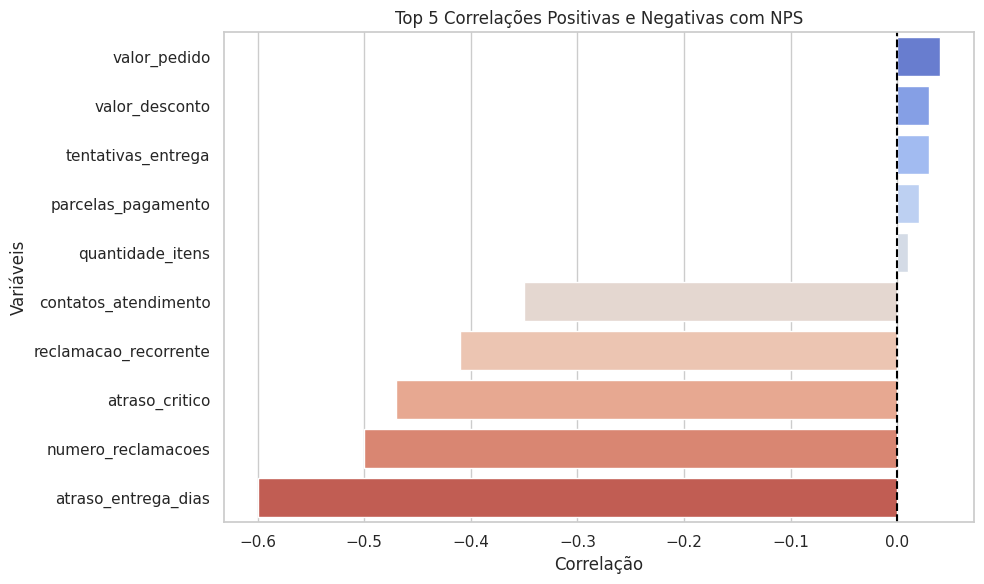

In [ ]:
plt.figure(figsize=(10,6))

sns.barplot(
    x=top_corr.values,
    y=top_corr.index,
    hue=top_corr.index,
    palette='coolwarm',
    legend=False
)

plt.axvline(0.0, color='black', linestyle='--')

plt.title('Top 5 Correlações Positivas e Negativas com NPS')
plt.xlabel('Correlação')
plt.ylabel('Variáveis')
plt.tight_layout()
plt.show()

### Interpretação

As correlações positivas com o NPS são relativamente fracas. Variáveis como `valor_pedido`, `valor_desconto`, `tentativas_entrega`, `parcelas_pagamento` e `quantidade_itens` apresentam associação positiva pequena com a satisfação dos clientes.

Já as correlações negativas são mais expressivas. A variável `atraso_entrega_dias` apresenta a relação negativa mais forte com o NPS, com correlação próxima de `-0.60`, indicando que maiores atrasos tendem a estar associados a menores níveis de satisfação.

Também se destacam `numero_reclamacoes`, `atraso_critico`, `reclamacao_recorrente` e `contatos_atendimento`, todas com associação negativa relevante com o NPS.

De forma geral, os resultados sugerem que fatores relacionados a atrasos, reclamações recorrentes e maior necessidade de atendimento estão mais associados à redução da satisfação do cliente do que fatores comerciais estão associados ao seu aumento.


# Considerações finais

A análise exploratória permitiu compreender a distribuição das variáveis e identificar os principais fatores associados à satisfação dos clientes.

### Visão geral do NPS

A variável `nps` apresentou média de **4,38**, em uma escala de 0 a 10.

A classificação dos clientes mostrou:

* aproximadamente **74% de detratores**;
* cerca de **8% de promotores**;
* predominância clara de clientes com baixa satisfação.

Esse resultado indica um cenário de insatisfação relevante e reforça a necessidade de investigar os fatores associados a essa percepção negativa.

### Principais fatores identificados

Entre as variáveis analisadas, `atraso_entrega_dias` e `numero_reclamacoes` apresentaram as diferenças mais evidentes entre detratores, neutros e promotores.

Na análise por faixas de atraso, observou-se uma redução consistente do NPS conforme o atraso aumentou:

* clientes sem atraso apresentaram média de **6,86**;
* clientes com atrasos superiores a 6 dias registraram média de apenas **0,24**;
* o percentual de detratores aumentou progressivamente entre as faixas.

Esses resultados indicam que atrasos superiores a 2 dias representam um cenário especialmente crítico para a experiência do cliente.

O número de reclamações também apresentou forte associação com o NPS. Clientes com maior recorrência de problemas concentraram-se em níveis mais baixos de satisfação, enquanto os promotores apresentaram menor quantidade de reclamações.

### Análise de correlação

A análise de correlação reforçou os padrões observados anteriormente.

As correlações positivas com o NPS foram relativamente fracas, enquanto as correlações negativas apresentaram maior intensidade.

Entre as principais relações negativas, destacaram-se:

* `atraso_entrega_dias`, com correlação próxima de `-0.60`;
* `numero_reclamacoes`;
* `atraso_critico`;
* `reclamacao_recorrente`;
* `contatos_atendimento`.

De forma geral, fatores relacionados a atrasos, recorrência de reclamações e necessidade de atendimento apresentaram associação mais forte com a redução do NPS do que fatores comerciais com o seu aumento.

### Variáveis derivadas

Com base nos padrões identificados, foram criadas três variáveis derivadas:

* `atraso_critico`: identifica clientes com atraso igual ou superior a 2 dias;
* `problema_complexo`: representa situações com múltiplos contatos e maior tempo de resolução;
* `reclamacao_recorrente`: identifica clientes com três ou mais reclamações.

As comparações mostraram que clientes expostos a essas situações apresentam notas de NPS inferiores.

Entre as variáveis derivadas, `reclamacao_recorrente` apresentou a separação mais evidente entre os grupos.

### Principais conclusões do EDA

De forma geral, os resultados indicam que a satisfação dos clientes está fortemente associada à eficiência operacional e à qualidade da resolução de problemas.

Os principais pontos de atenção identificados foram:

* cumprimento dos prazos de entrega;
* redução da recorrência de reclamações;
* diminuição de falhas operacionais;
* maior agilidade na resolução de problemas;
* redução da necessidade de múltiplos contatos com o atendimento.

Esses fatores aparecem como pontos prioritários para melhoria da experiência do cliente.

### Próxima etapa

Os padrões identificados nesta análise servirão como base para a etapa de Machine Learning.

Na modelagem, será avaliada a capacidade das variáveis originais e derivadas de explicar e prever a ocorrência de clientes detratores.

Por fim, é importante destacar que os resultados desta análise representam **associações observadas na base** e não comprovam relações de causa e efeito.
